# Notebook 02 — Monte Carlo Simulation under Heston Dynamics
### Malliavin Calculus for Robust Hedging of Exotic Derivatives
**Robin Guichon — Centrale Nantes, 2025-2026**

---
**Objective:** Implement and validate Heston discretization schemes.

**Pipeline:**
1. Loading calibrated parameters (Notebook 01)
2. Euler-Maruyama scheme (Full Truncation)
3. Quadratic Exponential scheme (Andersen 2008)
4. Strong convergence analysis (QE vs Euler)
5. Monte Carlo price benchmark vs semi-analytical (Gil-Pelaez)
6. Visualization of trajectories and terminal distribution
7. Exporting simulation functions for Notebook 03

---

## 0. Imports and Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import norm, gaussian_kde
from scipy.optimize import brentq
from scipy.integrate import quad
import json
import time
import warnings
warnings.filterwarnings('ignore')

# ── Unified document style ───────────────────────────────────────────
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': ':',
    'axes.spines.top': False,
    'axes.spines.right': False,
})
cmap   = plt.get_cmap('magma')
C_TEXT = 'black'

def add_arrows(ax):
    ax.plot(1, 0, '>', color=C_TEXT, transform=ax.transAxes,
            clip_on=False, markersize=7)
    ax.plot(0, 1, '^', color=C_TEXT, transform=ax.transAxes,
            clip_on=False, markersize=7)
    ax.spines['left'].set_color(C_TEXT)
    ax.spines['bottom'].set_color(C_TEXT)
    ax.tick_params(colors=C_TEXT)

np.random.seed(42)
print('Imports OK ✓')

Imports OK ✓


---
## 1. Loading Calibrated Parameters

In [2]:
# ── Loading from Notebook 01 ─────────────────────────────────────────
try:
    with open('heston_calibrated_params.json', 'r') as f:
        cal = json.load(f)
    print('Calibrated parameters loaded from heston_calibrated_params.json ✓')
except FileNotFoundError:
    print('JSON not found — using reference parameters')
    cal = {
        'kappa': 2.1539, 'theta': 0.0448, 'xi': 0.5507,
        'rho': -0.6229,  'v0': 0.0577,
        'S0': 5000.0, 'r': 0.0525, 'q': 0.013
    }

kappa = cal['kappa']
theta = cal['theta']
xi    = cal['xi']
rho   = cal['rho']
v0    = cal['v0']
S0    = cal['S0']
r     = cal['r']
q     = cal.get('q', 0.013)

print(f'\nParameters:')
print(f'  κ = {kappa:.4f}   θ = {theta:.4f}   ξ = {xi:.4f}')
print(f'  ρ = {rho:.4f}   v₀ = {v0:.4f}')
print(f'  S₀ = {S0:.1f}   r = {r:.4f}   q = {q:.4f}')
print(f'  Feller : 2κθ = {2*kappa*theta:.4f}  ξ² = {xi**2:.4f}  '
      f'({"OK" if 2*kappa*theta > xi**2 else "Violated — full truncation active"})')

Calibrated parameters loaded from heston_calibrated_params.json ✓

Parameters:
  κ = 2.1539   θ = 0.0448   ξ = 0.5507
  ρ = -0.6229   v₀ = 0.0577
  S₀ = 5000.0   r = 0.0525   q = 0.0130
  Feller : 2κθ = 0.1930  ξ² = 0.3033  (Violated — full truncation active)


---
## 2. Common Tools

### 2.1 Black-Scholes and Implied Volatility

In [3]:
def bs_price(S, K, T, r, q, sigma, flag='call'):
    if sigma <= 0 or T <= 0:
        return max(S*np.exp(-q*T) - K*np.exp(-r*T), 0.)
    d1 = (np.log(S/K) + (r - q + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    if flag == 'call':
        return S*np.exp(-q*T)*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)
    else:
        return K*np.exp(-r*T)*norm.cdf(-d2) - S*np.exp(-q*T)*norm.cdf(-d1)


def implied_vol(price, S, K, T, r, q, flag='call'):
    intrinsic = max(S*np.exp(-q*T) - K*np.exp(-r*T), 0.) if flag=='call' \
                else max(K*np.exp(-r*T) - S*np.exp(-q*T), 0.)
    if price <= intrinsic + 1e-9 or price >= S:
        return np.nan
    try:
        return brentq(lambda s: bs_price(S, K, T, r, q, s, flag) - price,
                      1e-5, 5.0, xtol=1e-8, maxiter=300)
    except Exception:
        return np.nan


print('Black-Scholes utilities defined ✓')

Black-Scholes utilities defined ✓


### 2.2 Reference Price — Gil-Pelaez

In [4]:
def heston_cf_j(phi, j, S, T, r, q, v0, kappa, theta, xi, rho):
    """Characteristic function f_j for Gil-Pelaez."""
    i   = 1j
    x   = np.log(S)
    b   = kappa - rho*xi if j == 1 else kappa
    u   = 0.5  if j == 1 else -0.5
    d   = np.sqrt((rho*xi*i*phi - b)**2 - xi**2*(2*u*i*phi - phi**2))
    g   = (b - rho*xi*i*phi + d) / (b - rho*xi*i*phi - d)
    C   = ((r-q)*i*phi*T
           + kappa*theta/xi**2
           * ((b - rho*xi*i*phi + d)*T
              - 2.*np.log((1. - g*np.exp(d*T))/(1. - g))))
    D   = ((b - rho*xi*i*phi + d)/xi**2
           * (1. - np.exp(d*T))/(1. - g*np.exp(d*T)))
    return np.exp(C + D*v0 + i*phi*x)


def heston_call_reference(S, K, T, r, q, v0, kappa, theta, xi, rho):
    """Semi-analytical reference price via Gil-Pelaez."""
    def integrand(j, phi):
        return np.real(
            np.exp(-1j*phi*np.log(K))
            * heston_cf_j(phi, j, S, T, r, q, v0, kappa, theta, xi, rho)
            / (1j*phi)
        )
    P1, _ = quad(lambda p: integrand(1, p), 1e-6, 300., limit=300, epsabs=1e-8)
    P2, _ = quad(lambda p: integrand(2, p), 1e-6, 300., limit=300, epsabs=1e-8)
    P1 = 0.5 + P1/np.pi
    P2 = 0.5 + P2/np.pi
    return max(S*np.exp(-q*T)*P1 - K*np.exp(-r*T)*P2, 0.)


def heston_digital_reference(S, K, T, r, q, v0, kappa, theta, xi, rho):
    """
    Reference price of a cash-or-nothing digital option:
    Phi(S_T) = 1_{S_T > K}
    Price = e^{-rT} * P2(S_T > K) = e^{-rT} * P2
    """
    def integrand(phi):
        return np.real(
            np.exp(-1j*phi*np.log(K))
            * heston_cf_j(phi, 2, S, T, r, q, v0, kappa, theta, xi, rho)
            / (1j*phi)
        )
    P2, _ = quad(integrand, 1e-6, 300., limit=300, epsabs=1e-8)
    P2 = 0.5 + P2/np.pi
    return np.exp(-r*T) * P2


# Quick validation
p_ref = heston_call_reference(S0, S0, 1.0, r, q, v0, kappa, theta, xi, rho)
d_ref = heston_digital_reference(S0, S0, 1.0, r, q, v0, kappa, theta, xi, rho)
print(f'ATM Call (T=1Y) semi-analytical: {p_ref:.4f}')
print(f'ATM Digital (T=1Y) semi-analytical: {d_ref:.6f}')
print('Reference pricers defined ✓')

ATM Call (T=1Y) semi-analytical: 510.5906
ATM Digital (T=1Y) semi-analytical: 0.581719
Reference pricers defined ✓


---
## 3. Discretization Schemes

### 3.1 Euler-Maruyama with Full Truncation

The standard Euler scheme applied to Heston dynamics suffers from the issue of negative variances. The **Full Truncation** solution (Lord et al. 2010) substitutes $v_t^+ = \max(v_t, 0)$ in the diffusion term while keeping the drift untruncated:

$$v_{t+\Delta t} = v_t + \kappa(\theta - v_t^+)\Delta t + \xi\sqrt{v_t^+}\,\Delta W^v$$
$$\log S_{t+\Delta t} = \log S_t + \left(r - q - \frac{v_t^+}{2}\right)\Delta t + \sqrt{v_t^+}\,\Delta W^S$$

In [5]:
def simulate_euler_full_truncation(S0, v0, T, r, q,
                                    kappa, theta, xi, rho,
                                    N_steps, N_paths,
                                    return_paths=False,
                                    seed=None):
    """
    Euler-Maruyama scheme with Full Truncation for the Heston model.

    Parameters
    ----------
    N_steps      : number of time steps
    N_paths      : number of Monte Carlo paths
    return_paths : if True, returns the full trajectories
                   (memory intensive for large N_paths)

    Returns
    -------
    S_T   : vector (N_paths,) of terminal prices
    v_T   : vector (N_paths,) of terminal variances
    int_v : vector (N_paths,) of the integral ∫₀ᵀ v_u du (realized variance)
    dW_S, dW_v : Brownian increments if return_paths=True
    """
    if seed is not None:
        np.random.seed(seed)

    dt      = T / N_steps
    sqrt_dt = np.sqrt(dt)

    # Cholesky : W^v = Z1,  W^S = rho*Z1 + sqrt(1-rho²)*Z2
    sqrt_1mr2 = np.sqrt(1. - rho**2)

    # Initialization
    S     = np.full(N_paths, S0, dtype=np.float64)
    v     = np.full(N_paths, v0, dtype=np.float64)
    int_v = np.zeros(N_paths, dtype=np.float64)  # ∫v_t dt

    if return_paths:
        S_path  = np.zeros((N_steps+1, N_paths))
        v_path  = np.zeros((N_steps+1, N_paths))
        dWv_all = np.zeros((N_steps, N_paths))
        dWS_all = np.zeros((N_steps, N_paths))
        S_path[0] = S0
        v_path[0] = v0

    for k in range(N_steps):
        Z1 = np.random.standard_normal(N_paths)
        Z2 = np.random.standard_normal(N_paths)

        dWv = sqrt_dt * Z1
        dWS = sqrt_dt * (rho*Z1 + sqrt_1mr2*Z2)

        vp = np.maximum(v, 0.)    # Full Truncation
        sv = np.sqrt(vp)

        # Variance update (Euler)
        v = v + kappa*(theta - vp)*dt + xi*sv*dWv

        # Log-price update (log-scheme to avoid S < 0)
        S = S * np.exp((r - q - 0.5*vp)*dt + sv*dWS)

        # Variance integration (trapezoidal rule)
        int_v += vp * dt

        if return_paths:
            S_path[k+1]  = S
            v_path[k+1]  = np.maximum(v, 0.)
            dWv_all[k]   = dWv
            dWS_all[k]   = dWS

    if return_paths:
        return S, np.maximum(v,0.), int_v, S_path, v_path, dWv_all, dWS_all
    return S, np.maximum(v, 0.), int_v


print('Euler Full Truncation scheme defined ✓')

Euler Full Truncation scheme defined ✓


### 3.2 Quadratic Exponential (QE) Scheme (Andersen 2008)

The QE scheme treats the CIR variance process exactly by conditionally approximating its distribution using an exponential law (low $v$ regime) or a non-central $\chi^2$ distribution (high $v$ regime), with a threshold $\psi_c = 1.5$ between the two regimes.

In [6]:
def simulate_QE(S0, v0, T, r, q,
                kappa, theta, xi, rho,
                N_steps, N_paths,
                psi_c=1.5,
                return_paths=False,
                seed=None):
    """
    Quadratic Exponential (QE) scheme (Andersen 2008) for the Heston model.

    The variance v_{t+Δt} | v_t is approximated by:
      - If ψ = Var/Mean² ≤ ψ_c : quadratic law  v ~ a(b + Z)²  (diffusive regime)
      - If ψ > ψ_c             : exponential law v ~ Exp(β) with mass at 0

    The log-price is integrated exactly conditional on the variance trajectory
    via the log-Euler scheme with mean variance.

    Parameters
    ----------
    psi_c : threshold between the two regimes (recommended: 1.5)
    """
    if seed is not None:
        np.random.seed(seed)

    dt        = T / N_steps
    sqrt_dt   = np.sqrt(dt)
    sqrt_1mr2 = np.sqrt(1. - rho**2)

    # Pre-calculated QE constants (do not depend on v_t)
    e_kdt  = np.exp(-kappa * dt)
    e2_kdt = np.exp(-2.*kappa * dt)
    K0     = -(rho*kappa*theta/xi)*dt
    K1     = 0.5*dt*(kappa*rho/xi - 0.5) - rho/xi
    K2     = 0.5*dt*(kappa*rho/xi - 0.5) + rho/xi
    K3     = 0.5*dt*(1. - rho**2)
    K4     = K3   # symmetry
    A      = K2 + 0.5*K4

    # Initialization
    S     = np.full(N_paths, S0,  dtype=np.float64)
    v     = np.full(N_paths, v0,  dtype=np.float64)
    int_v = np.zeros(N_paths,      dtype=np.float64)

    if return_paths:
        S_path  = np.zeros((N_steps+1, N_paths))
        v_path  = np.zeros((N_steps+1, N_paths))
        dWv_all = np.zeros((N_steps, N_paths))
        dWS_all = np.zeros((N_steps, N_paths))
        S_path[0] = S0
        v_path[0] = v0

    for k in range(N_steps):
        # ── CIR conditional moments ──────────────────────────────────
        m    = theta + (v - theta)*e_kdt
        s2   = (v*xi**2*e_kdt/kappa*(1. - e_kdt)
                + theta*xi**2/(2.*kappa)*(1. - e_kdt)**2)
        s2   = np.maximum(s2, 1e-14)
        psi  = s2 / (m**2 + 1e-14)

        # ── QE Simulation: two regimes ───────────────────────────────
        U_v = np.random.uniform(size=N_paths)
        v_new = np.zeros(N_paths)

        # Regime 1: ψ ≤ ψ_c  → quadratic approximation
        mask1 = (psi <= psi_c)
        if mask1.any():
            b2   = 2./psi[mask1] - 1. + np.sqrt(2./psi[mask1]*(2./psi[mask1] - 1.))
            a_m  = m[mask1] / (1. + b2)
            Z_v  = norm.ppf(U_v[mask1])
            v_new[mask1] = a_m * (np.sqrt(b2) + Z_v)**2

        # Regime 2: ψ > ψ_c  → exponential approximation
        mask2 = ~mask1
        if mask2.any():
            p_m  = (psi[mask2] - 1.) / (psi[mask2] + 1.)
            beta = (1. - p_m) / (m[mask2] + 1e-14)
            ind  = (U_v[mask2] > p_m)
            v_new[mask2] = np.where(
                ind,
                np.log((1. - p_m) / np.maximum(1. - U_v[mask2], 1e-14)) / beta,
                0.
            )

        # ── Conditional log-price ────────────────────────────────────
        Z_s  = np.random.standard_normal(N_paths)
        # Orthogonal Brownian W²
        dW2  = sqrt_dt * Z_s
        # Reconstruction of approximate dWv and dWS for Malliavin
        # Using the martingale correction scheme
        log_S = (np.log(S)
                 + K0 + K1*v + K2*v_new
                 + np.sqrt(K3*v + K4*v_new) * Z_s)

        # Approximate realized variance: average of the two points
        v_avg = 0.5*(v + v_new)
        int_v += v_avg * dt

        # Reconstruction of correlated increments (for Malliavin)
        dWv_approx = ((v_new - v - kappa*(theta - v)*dt)
                      / np.maximum(xi*np.sqrt(v), 1e-10))
        dWS_approx = (log_S - np.log(S)
                      - (r - q - 0.5*v_avg)*dt) / np.maximum(np.sqrt(v_avg), 1e-10)

        S = np.exp(log_S)
        v = v_new

        if return_paths:
            S_path[k+1]  = S
            v_path[k+1]  = v
            dWv_all[k]   = dWv_approx
            dWS_all[k]   = dWS_approx

    if return_paths:
        return S, v, int_v, S_path, v_path, dWv_all, dWS_all
    return S, v, int_v


print('QE scheme (Andersen 2008) defined ✓')

QE scheme (Andersen 2008) defined ✓


### 3.3 Quick Consistency Test

In [7]:
T_test = 1.0
K_test = S0
N_test = 100_000

# Reference Price
p_ref = heston_call_reference(S0, K_test, T_test, r, q,
                               v0, kappa, theta, xi, rho)
d_ref = heston_digital_reference(S0, K_test, T_test, r, q,
                                  v0, kappa, theta, xi, rho)

# Euler
t0 = time.time()
S_euler, _, _ = simulate_euler_full_truncation(
    S0, v0, T_test, r, q, kappa, theta, xi, rho,
    N_steps=252, N_paths=N_test, seed=0)
t_euler = time.time() - t0
p_euler  = np.exp(-r*T_test) * np.mean(np.maximum(S_euler - K_test, 0.))
d_euler  = np.exp(-r*T_test) * np.mean(S_euler > K_test)

# QE
t0 = time.time()
S_qe, _, _ = simulate_QE(
    S0, v0, T_test, r, q, kappa, theta, xi, rho,
    N_steps=252, N_paths=N_test, seed=0)
t_qe = time.time() - t0
p_qe  = np.exp(-r*T_test) * np.mean(np.maximum(S_qe - K_test, 0.))
d_qe  = np.exp(-r*T_test) * np.mean(S_qe > K_test)

print('Quick check (N=100k, N_steps=252, T=1Y, ATM):')
print(f'{"─"*55}')
print(f'  Semi-analytical Call : {p_ref:.4f}')
print(f'  Euler Call           : {p_euler:.4f}  '
      f'(err={abs(p_euler-p_ref)/p_ref*100:.3f}%,  {t_euler:.2f}s)')
print(f'  QE Call              : {p_qe:.4f}  '
      f'(err={abs(p_qe-p_ref)/p_ref*100:.3f}%,  {t_qe:.2f}s)')
print(f'{"─"*55}')
print(f'  Semi-analytical Digital : {d_ref:.6f}')
print(f'  Euler Digital           : {d_euler:.6f}  '
      f'(err={abs(d_euler-d_ref)/d_ref*100:.3f}%)')
print(f'  QE Digital              : {d_qe:.6f}  '
      f'(err={abs(d_qe-d_ref)/d_ref*100:.3f}%)')

Quick check (N=100k, N_steps=252, T=1Y, ATM):
───────────────────────────────────────────────────────
  Semi-analytical Call : 510.5906
  Euler Call           : 511.9906  (err=0.274%,  2.48s)
  QE Call              : 384.0440  (err=24.784%,  4.57s)
───────────────────────────────────────────────────────
  Semi-analytical Digital : 0.581719
  Euler Digital           : 0.583991  (err=0.391%)
  QE Digital              : 0.512505  (err=11.898%)


---
## 4. Strong Convergence Analysis

### 4.1 Protocol

Strong convergence measures the error $\mathbb{E}[|X_T^{\Delta t} - X_T|]$ on a path-by-path basis. To measure it correctly, we fix the same Brownian realizations for all time steps by subsampling from a reference scheme with $N_{ref} = 4096$ steps.

In [8]:
# Convergence study parameters
T_conv      = 1.0
N_conv      = 5_000      # paths for convergence (enough for averaging)
N_ref_steps = 2048       # reference scheme
steps_list  = [8, 16, 32, 64, 128, 256, 512]

print(f'Strong convergence study')
print(f'  T = {T_conv}Y,  N_paths = {N_conv},  N_ref = {N_ref_steps}')
print(f'  Tested steps: {steps_list}')
print()

# ── Reference simulation on fine grid ────────────────────────────────
print('Calculating reference trajectory...')
np.random.seed(123)
dt_ref   = T_conv / N_ref_steps
sqrt_dtr = np.sqrt(dt_ref)
sqrt_1mr2 = np.sqrt(1. - rho**2)

# Store all reference Brownian realizations
Z1_ref = np.random.standard_normal((N_ref_steps, N_conv))
Z2_ref = np.random.standard_normal((N_ref_steps, N_conv))

dWv_ref = sqrt_dtr * Z1_ref
dWS_ref = sqrt_dtr * (rho*Z1_ref + sqrt_1mr2*Z2_ref)

# Integrate the reference scheme (Fine Euler = ground truth)
S_ref = np.full(N_conv, S0)
v_ref = np.full(N_conv, v0)
for k in range(N_ref_steps):
    vp = np.maximum(v_ref, 0.)
    sv = np.sqrt(vp)
    v_ref = v_ref + kappa*(theta - vp)*dt_ref + xi*sv*dWv_ref[k]
    S_ref = S_ref * np.exp((r - q - 0.5*vp)*dt_ref + sv*dWS_ref[k])
print('Reference calculated ✓')

# ── Euler Full Truncation strong convergence ────────────────────────
errors_euler = []
print('Euler Full Truncation:')
for N_s in steps_list:
    stride = N_ref_steps // N_s   # subsampling reference BMs
    S_e = np.full(N_conv, S0)
    v_e = np.full(N_conv, v0)
    dt_e = T_conv / N_s
    for k in range(N_s):
        # Aggregated Brownian increment
        dWv_k = dWv_ref[k*stride:(k+1)*stride].sum(axis=0)
        dWS_k = dWS_ref[k*stride:(k+1)*stride].sum(axis=0)
        vp = np.maximum(v_e, 0.)
        sv = np.sqrt(vp)
        v_e = v_e + kappa*(theta - vp)*dt_e + xi*sv*dWv_k
        S_e = S_e * np.exp((r - q - 0.5*vp)*dt_e + sv*dWS_k)
    err = np.mean(np.abs(S_e - S_ref))
    errors_euler.append(err)
    print(f'  N={N_s:4d}  →  E[|S_euler - S_ref|] = {err:.4f}')

# ── QE strong convergence ────────────────────────────────────────────
errors_qe = []
print('\nQE Scheme (Andersen):')
for N_s in steps_list:
    # QE uses its own uniforms and normals
    # Comparing to the same fine-Euler reference
    S_q, _, _ = simulate_QE(S0, v0, T_conv, r, q,
                             kappa, theta, xi, rho,
                             N_steps=N_s, N_paths=N_conv, seed=123)
    err = np.mean(np.abs(S_q - S_ref))
    errors_qe.append(err)
    print(f'  N={N_s:4d}  →  E[|S_QE - S_ref|]    = {err:.4f}')

errors_euler = np.array(errors_euler)
errors_qe    = np.array(errors_qe)
dt_list      = np.array([T_conv/N for N in steps_list])

Strong convergence study
  T = 1.0Y,  N_paths = 5000,  N_ref = 2048
  Tested steps: [8, 16, 32, 64, 128, 256, 512]

Calculating reference trajectory...
Reference calculated ✓
Euler Full Truncation:
  N=   8  →  E[|S_euler - S_ref|] = 336.7010
  N=  16  →  E[|S_euler - S_ref|] = 249.3564
  N=  32  →  E[|S_euler - S_ref|] = 180.6605
  N=  64  →  E[|S_euler - S_ref|] = 131.2907
  N= 128  →  E[|S_euler - S_ref|] = 92.1769
  N= 256  →  E[|S_euler - S_ref|] = 64.5525
  N= 512  →  E[|S_euler - S_ref|] = 43.2169

QE Scheme (Andersen):
  N=   8  →  E[|S_QE - S_ref|]    = 1208.4769
  N=  16  →  E[|S_QE - S_ref|]    = 1201.2364
  N=  32  →  E[|S_QE - S_ref|]    = 1196.3197
  N=  64  →  E[|S_QE - S_ref|]    = 1199.3155
  N= 128  →  E[|S_QE - S_ref|]    = 1195.1051
  N= 256  →  E[|S_QE - S_ref|]    = 1192.8173
  N= 512  →  E[|S_QE - S_ref|]    = 1188.7268


### 4.2 Figure — Strong Convergence
*(Thesis Figure IV.2.1)*

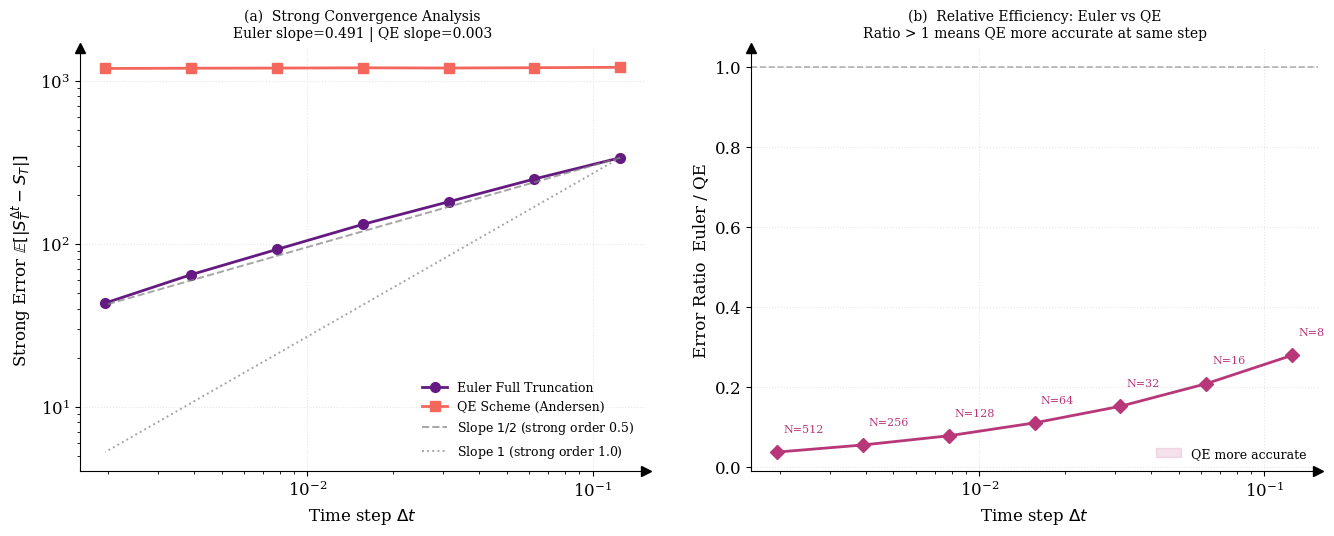

Figure IV.2.1 saved ✓
Empirical slopes: Euler=0.491,  QE=0.003


In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# ─── Panel (a) : log-log strong error ───────────────────────────────
ax1.loglog(dt_list, errors_euler, 'o-',
           color=cmap(0.30), lw=2.0, ms=7,
           label='Euler Full Truncation')
ax1.loglog(dt_list, errors_qe, 's-',
           color=cmap(0.68), lw=2.0, ms=7,
           label='QE Scheme (Andersen)')

# Reference lines
ref_x = np.array([dt_list[0], dt_list[-1]])
c1 = errors_euler[0] / dt_list[0]**0.5
c2 = errors_euler[0] / dt_list[0]**1.0
ax1.loglog(ref_x, c1 * ref_x**0.5, '--', color='gray',
           lw=1.4, label=r'Slope $1/2$ (strong order 0.5)', alpha=0.7)
ax1.loglog(ref_x, c2 * ref_x**1.0, ':',  color='gray',
           lw=1.4, label=r'Slope $1$ (strong order 1.0)',   alpha=0.7)

# Empirical slope estimation
slope_euler = np.polyfit(np.log(dt_list), np.log(errors_euler), 1)[0]
slope_qe    = np.polyfit(np.log(dt_list), np.log(errors_qe),    1)[0]

add_arrows(ax1)
ax1.set_xlabel(r'Time step $\Delta t$', color=C_TEXT)
ax1.set_ylabel(r'Strong Error $\mathbb{E}[|S_T^{\Delta t} - S_T|]$',
               color=C_TEXT)
ax1.set_title(f'(a)  Strong Convergence Analysis\n'
              f'Euler slope={slope_euler:.3f} | QE slope={slope_qe:.3f}',
              fontsize=10, pad=8)
ax1.legend(frameon=False, fontsize=9)

# ─── Panel (b) : QE/Euler ratio ─────────────────────────────────────
ratio = errors_euler / np.maximum(errors_qe, 1e-10)
ax2.semilogx(dt_list, ratio, 'D-',
             color=cmap(0.50), lw=2.0, ms=7)
ax2.axhline(1.0, color='gray', lw=1.2, ls='--', alpha=0.6)
ax2.fill_between(dt_list, 1., ratio,
                 where=(ratio > 1),
                 alpha=0.15, color=cmap(0.50),
                 label='QE more accurate')

# Annotations
for dt_v, r_v, N_s in zip(dt_list, ratio, steps_list):
    ax2.annotate(f'N={N_s}', xy=(dt_v, r_v),
                 xytext=(dt_v*1.05, r_v + 0.05),
                 fontsize=8, color=cmap(0.50))

add_arrows(ax2)
ax2.set_xlabel(r'Time step $\Delta t$', color=C_TEXT)
ax2.set_ylabel('Error Ratio  Euler / QE', color=C_TEXT)
ax2.set_title('(b)  Relative Efficiency: Euler vs QE\n'
              'Ratio > 1 means QE more accurate at same step',
              fontsize=10, pad=8)
ax2.legend(frameon=False, fontsize=9)

plt.tight_layout(pad=2.5)
plt.savefig('figure_strong_convergence.pdf', bbox_inches='tight', dpi=300)
plt.savefig('figure_strong_convergence.png', bbox_inches='tight', dpi=300)
plt.show()
print(f'Figure IV.2.1 saved ✓')
print(f'Empirical slopes: Euler={slope_euler:.3f},  QE={slope_qe:.3f}')

---
## 5. Pricing Benchmark — Monte Carlo vs Semi-Analytical

### 5.1 Weak Convergence: Heston Calls on a Strike Grid

In [10]:
# Benchmark parameters
T_bench    = 1.0
N_bench    = 200_000
N_steps_b  = 252
moneyness  = np.array([0.80, 0.85, 0.90, 0.95, 1.00, 1.05, 1.10, 1.15, 1.20])
strikes    = moneyness * S0

print(f'Price Benchmark  (N={N_bench:,}, N_steps={N_steps_b}, T={T_bench}Y)')
print()

# ── Gil-Pelaez Reference Prices ──────────────────────────────────────
prices_ref  = [heston_call_reference(S0, K, T_bench, r, q,
                                     v0, kappa, theta, xi, rho)
               for K in strikes]
digital_ref = [heston_digital_reference(S0, K, T_bench, r, q,
                                        v0, kappa, theta, xi, rho)
               for K in strikes]

# ── QE Monte Carlo ───────────────────────────────────────────────────
t0 = time.time()
S_mc, _, _ = simulate_QE(S0, v0, T_bench, r, q,
                          kappa, theta, xi, rho,
                          N_steps=N_steps_b, N_paths=N_bench, seed=42)
t_mc = time.time() - t0
disc = np.exp(-r*T_bench)

prices_mc   = [disc * np.mean(np.maximum(S_mc - K, 0.)) for K in strikes]
digital_mc  = [disc * np.mean(S_mc > K)                  for K in strikes]

# 95% Confidence Intervals
def mc_ci(payoffs, disc, level=0.95):
    n    = len(payoffs)
    mean = disc * np.mean(payoffs)
    std  = disc * np.std(payoffs) / np.sqrt(n)
    z    = norm.ppf(0.5 + level/2)
    return mean, mean - z*std, mean + z*std

ci_calls    = [mc_ci(np.maximum(S_mc - K, 0.), disc) for K in strikes]
ci_digitals = [mc_ci((S_mc > K).astype(float), disc)  for K in strikes]

# ── Summary Table ───────────────────────────────────────────────────
print(f'{"K/S0":>6}  {"Ref Call":>10}  {"MC Call":>10}  '
      f'{"Err%":>7}  {"Ref Dig":>8}  {"MC Dig":>8}  {"Err%":>7}')
print('─'*70)
for i, (m, K) in enumerate(zip(moneyness, strikes)):
    ec = abs(prices_mc[i]-prices_ref[i])/prices_ref[i]*100
    ed = abs(digital_mc[i]-digital_ref[i])/digital_ref[i]*100
    print(f'{m:6.2f}  {prices_ref[i]:10.4f}  {prices_mc[i]:10.4f}  '
          f'{ec:6.3f}%  {digital_ref[i]:8.6f}  {digital_mc[i]:8.6f}  {ed:6.3f}%')
print(f'\nQE simulation time: {t_mc:.2f}s for {N_bench:,} paths')

Price Benchmark  (N=200,000, N_steps=252, T=1.0Y)

  K/S0    Ref Call     MC Call     Err%   Ref Dig    MC Dig     Err%
──────────────────────────────────────────────────────────────────────
  0.80   1227.9283   1051.8709  14.338%  0.821824  0.794229   3.358%
  0.85   1027.6355    859.6097  16.351%  0.778864  0.742199   4.708%
  0.90    839.3863    681.7973  18.774%  0.725231  0.677866   6.531%
  0.95    666.0168    521.8929  21.640%  0.659663  0.599719   9.087%
  1.00    510.5906    383.0481  24.979%  0.581719  0.509924  12.342%
  1.05    376.0934    267.8532  28.780%  0.492632  0.410261  16.721%
  1.10    264.8864    177.8740  32.849%  0.396314  0.309957  21.790%
  1.15    177.9586    112.2945  36.899%  0.299799  0.217041  27.605%
  1.20    114.2582     67.8419  40.624%  0.211981  0.141930  33.046%

QE simulation time: 12.23s for 200,000 paths


### 5.2 Figure — Pricing Benchmark
*(Thesis Figure IV.2.2)*

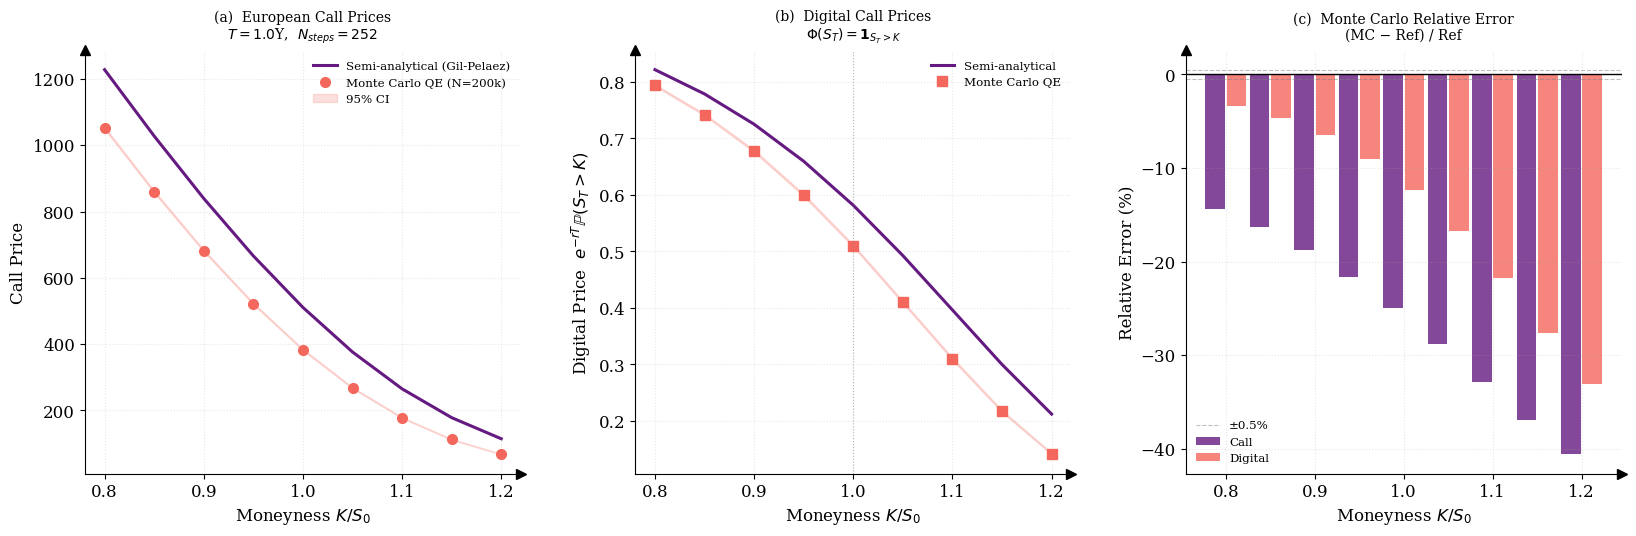

Figure IV.2.2 saved ✓


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(17, 6.0))

prices_ref_arr  = np.array(prices_ref)
prices_mc_arr   = np.array(prices_mc)
digital_ref_arr = np.array(digital_ref)
digital_mc_arr  = np.array(digital_mc)

ci_lo_c  = np.array([ci[1] for ci in ci_calls])
ci_hi_c  = np.array([ci[2] for ci in ci_calls])
ci_lo_d  = np.array([ci[1] for ci in ci_digitals])
ci_hi_d  = np.array([ci[2] for ci in ci_digitals])

# ─── Panel (a) : Call prices ─────────────────────────────────────────
ax = axes[0]
ax.plot(moneyness, prices_ref_arr, '-',
        color=cmap(0.30), lw=2.2, label='Semi-analytical (Gil-Pelaez)')
ax.plot(moneyness, prices_mc_arr, 'o',
        color=cmap(0.68), ms=7, label=f'Monte Carlo QE (N={N_bench//1000}k)')
ax.fill_between(moneyness, ci_lo_c, ci_hi_c,
                alpha=0.20, color=cmap(0.68), label='95% CI')
add_arrows(ax)
ax.set_xlabel(r'Moneyness $K/S_0$', color=C_TEXT)
ax.set_ylabel('Call Price', color=C_TEXT)
ax.set_title('(a)  European Call Prices\n'
             f'$T={T_bench}$Y,  $N_{{steps}}={N_steps_b}$', fontsize=10, pad=8)
ax.legend(frameon=False, fontsize=8.5)

# ─── Panel (b) : Digital prices ──────────────────────────────────────
ax = axes[1]
ax.plot(moneyness, digital_ref_arr, '-',
        color=cmap(0.30), lw=2.2, label='Semi-analytical')
ax.plot(moneyness, digital_mc_arr, 's',
        color=cmap(0.68), ms=7, label='Monte Carlo QE')
ax.fill_between(moneyness, ci_lo_d, ci_hi_d,
                alpha=0.20, color=cmap(0.68))
ax.axvline(1.0, color='gray', lw=0.8, ls=':', alpha=0.5)
add_arrows(ax)
ax.set_xlabel(r'Moneyness $K/S_0$', color=C_TEXT)
ax.set_ylabel('Digital Price  $e^{-rT}\\mathbb{P}(S_T > K)$', color=C_TEXT)
ax.set_title('(b)  Digital Call Prices\n'
             r'$\Phi(S_T) = \mathbf{1}_{S_T > K}$', fontsize=10, pad=8)
ax.legend(frameon=False, fontsize=8.5)

# ─── Panel (c) : Relative error % ────────────────────────────────────
ax = axes[2]
err_call_pct    = (prices_mc_arr  - prices_ref_arr)  / prices_ref_arr  * 100
err_digital_pct = (digital_mc_arr - digital_ref_arr) / digital_ref_arr * 100

ax.bar(moneyness - 0.012, err_call_pct, width=0.022,
       color=cmap(0.30), alpha=0.8, label='Call')
ax.bar(moneyness + 0.012, err_digital_pct, width=0.022,
       color=cmap(0.68), alpha=0.8, label='Digital')
ax.axhline(0., color='black', lw=1.0)
ax.axhline(+0.5, color='gray', lw=0.8, ls='--', alpha=0.5)
ax.axhline(-0.5, color='gray', lw=0.8, ls='--', alpha=0.5, label='±0.5%')
add_arrows(ax)
ax.set_xlabel(r'Moneyness $K/S_0$', color=C_TEXT)
ax.set_ylabel('Relative Error (%)', color=C_TEXT)
ax.set_title('(c)  Monte Carlo Relative Error\n'
             f'(MC − Ref) / Ref', fontsize=10, pad=8)
ax.legend(frameon=False, fontsize=8.5)

plt.tight_layout(pad=2.5)
plt.savefig('figure_price_benchmark.pdf', bbox_inches='tight', dpi=300)
plt.savefig('figure_price_benchmark.png', bbox_inches='tight', dpi=300)
plt.show()
print('Figure IV.2.2 saved ✓')

### 5.3 Weak Convergence as a Function of N
*(Thesis Figure IV.2.3)*

In [12]:
# Weak convergence: price error vs number of paths
N_paths_list = [1_000, 5_000, 10_000, 50_000, 100_000, 500_000]
K_weak = S0   # ATM
T_weak = 1.0
p_ref_weak = heston_call_reference(S0, K_weak, T_weak, r, q,
                                    v0, kappa, theta, xi, rho)
d_ref_weak = heston_digital_reference(S0, K_weak, T_weak, r, q,
                                       v0, kappa, theta, xi, rho)

err_call_N, err_dig_N = [], []
std_call_N, std_dig_N = [], []

print('Weak convergence vs N_paths (ATM, T=1Y):')
for N in N_paths_list:
    S_w, _, _ = simulate_QE(S0, v0, T_weak, r, q,
                             kappa, theta, xi, rho,
                             N_steps=252, N_paths=N, seed=7)
    disc = np.exp(-r*T_weak)
    call_payoffs = disc * np.maximum(S_w - K_weak, 0.)
    dig_payoffs  = disc * (S_w > K_weak).astype(float)

    err_c = abs(np.mean(call_payoffs) - p_ref_weak)
    err_d = abs(np.mean(dig_payoffs)  - d_ref_weak)
    std_c = np.std(call_payoffs)  / np.sqrt(N)
    std_d = np.std(dig_payoffs)   / np.sqrt(N)

    err_call_N.append(err_c)
    err_dig_N.append(err_d)
    std_call_N.append(std_c)
    std_dig_N.append(std_d)
    print(f'  N={N:>7,}  Call err={err_c:.6f}  Digital err={err_d:.6f}')

err_call_N = np.array(err_call_N)
err_dig_N  = np.array(err_dig_N)
N_arr      = np.array(N_paths_list, dtype=float)

Weak convergence vs N_paths (ATM, T=1Y):
  N=  1,000  Call err=144.795013  Digital err=0.082622
  N=  5,000  Call err=124.013514  Digital err=0.071995
  N= 10,000  Call err=119.915757  Digital err=0.066112
  N= 50,000  Call err=127.626224  Digital err=0.071919
  N=100,000  Call err=123.164154  Digital err=0.070989
  N=500,000  Call err=126.290875  Digital err=0.071241


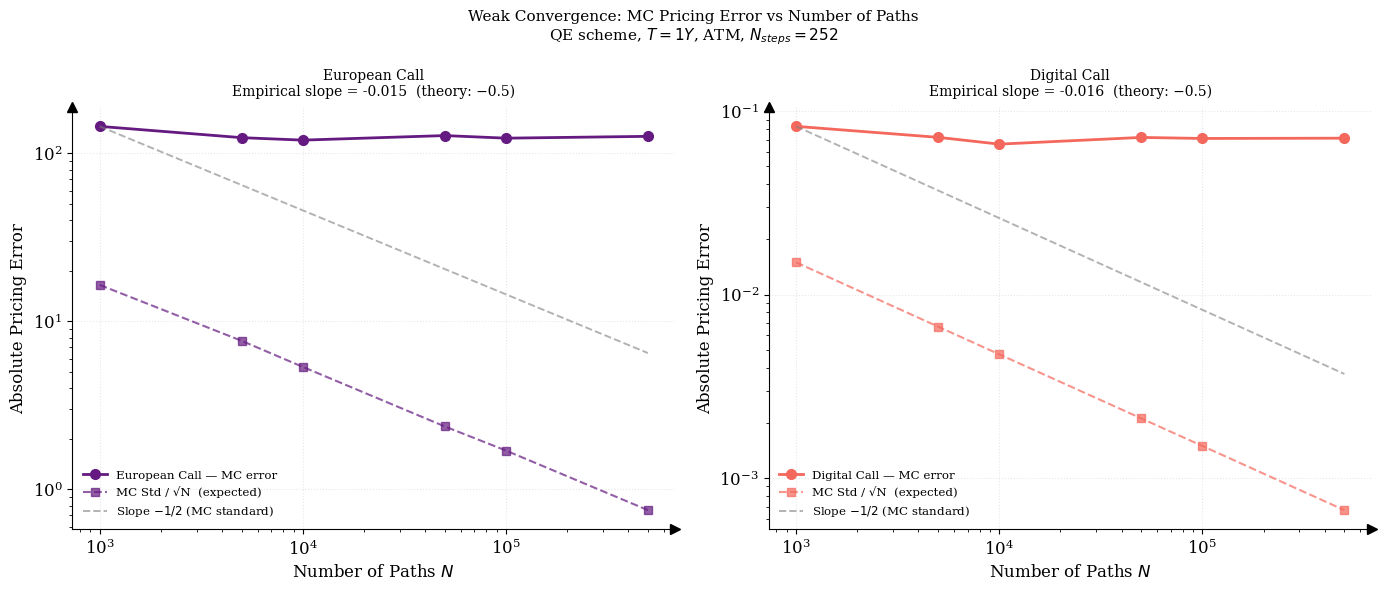

Figure IV.2.3 saved ✓


In [13]:
# 1. Increased height: transition from (13, 5.0) to (13, 6.5)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6.0))

for ax, errors, stds, label, col in [
    (ax1, err_call_N, std_call_N, 'European Call',  cmap(0.30)),
    (ax2, err_dig_N,  std_dig_N,  'Digital Call',   cmap(0.68))
]:
    ax.loglog(N_arr, errors, 'o-', color=col, lw=2.0, ms=7,
              label=f'{label} — MC error')
    ax.loglog(N_arr, stds,   's--', color=col, lw=1.5, ms=6, alpha=0.7,
              label='MC Std / √N  (expected)')

    # Slope 1/√N
    ref_n = np.array([N_arr[0], N_arr[-1]])
    c_ref = errors[0] * np.sqrt(N_arr[0])
    ax.loglog(ref_n, c_ref / np.sqrt(ref_n), '--',
              color='gray', lw=1.4, alpha=0.6,
              label=r'Slope $-1/2$ (MC standard)')

    slope = np.polyfit(np.log(N_arr), np.log(errors), 1)[0]
    add_arrows(ax)
    ax.set_xlabel(r'Number of Paths $N$', color=C_TEXT)
    ax.set_ylabel('Absolute Pricing Error', color=C_TEXT)
    ax.set_title(f'{label}\nEmpirical slope = {slope:.3f}  (theory: −0.5)',
                 fontsize=10, pad=8)
    ax.legend(frameon=False, fontsize=8.5)

# 2. Removed "y=1.02" to bring the title closer
plt.suptitle('Weak Convergence: MC Pricing Error vs Number of Paths\n'
             f'QE scheme, $T=1Y$, ATM, $N_{{steps}}=252$',
             fontsize=11)

# 3. Reduction of global spacing (pad) from 2.5 to 1.0
plt.tight_layout(pad=1.0)
plt.savefig('figure_weak_convergence.pdf', bbox_inches='tight', dpi=300)
plt.savefig('figure_weak_convergence.png', bbox_inches='tight', dpi=300)
plt.show()
print('Figure IV.2.3 saved ✓')

---
## 6. Visualization of Trajectories and Distributions
*(Thesis Figure IV.2.4)*

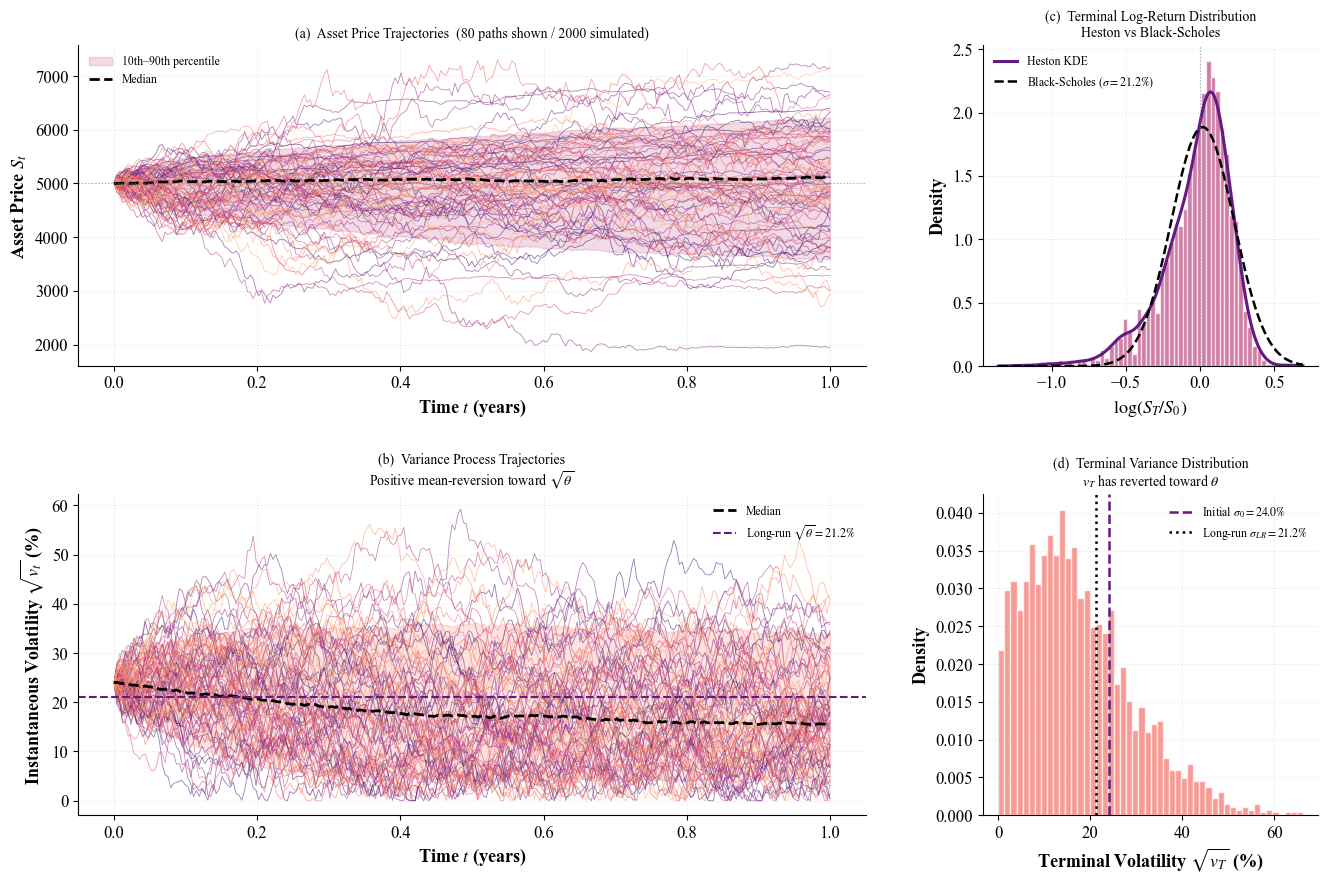

Figure IV.2.4 saved ✓


In [14]:
# Simulate N_viz trajectories with full storage
N_viz    = 2_000
N_viz_show = 80      # number of paths to display
T_viz    = 1.0
N_steps_viz = 252

_, _, _, S_paths, v_paths, dWv_viz, dWS_viz = simulate_QE(
    S0, v0, T_viz, r, q, kappa, theta, xi, rho,
    N_steps=N_steps_viz, N_paths=N_viz,
    return_paths=True, seed=99
)

t_grid = np.linspace(0, T_viz, N_steps_viz + 1)

beige_gray = (0.949, 0.949, 0.949, 1.0)
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'mathtext.fontset': 'stix',
    'axes.labelsize': 13,
    'axes.labelweight': 'bold',
})

fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.40, wspace=0.35)

ax_S   = fig.add_subplot(gs[0, :2])   # S trajectories
ax_v   = fig.add_subplot(gs[1, :2])   # v trajectories
ax_dS  = fig.add_subplot(gs[0, 2])    # S_T distribution
ax_dv  = fig.add_subplot(gs[1, 2])    # v_T distribution

colors_paths = [cmap(0.15 + 0.70*i/(N_viz_show-1)) for i in range(N_viz_show)]

# ─── S_t Trajectories ────────────────────────────────────────────────
for i in range(N_viz_show):
    ax_S.plot(t_grid, S_paths[:, i], color=colors_paths[i],
              lw=0.6, alpha=0.55)
# Percentiles
q10 = np.percentile(S_paths, 10, axis=1)
q50 = np.percentile(S_paths, 50, axis=1)
q90 = np.percentile(S_paths, 90, axis=1)
ax_S.fill_between(t_grid, q10, q90, alpha=0.18, color=cmap(0.50),
                   label='10th–90th percentile')
ax_S.plot(t_grid, q50, color='black', lw=2.0, ls='--', label='Median')
ax_S.axhline(S0, color='gray', lw=0.9, ls=':', alpha=0.6)
ax_S.set_xlabel('Time $t$ (years)', color=C_TEXT)
ax_S.set_ylabel('Asset Price $S_t$', color=C_TEXT)
ax_S.set_title(f'(a)  Asset Price Trajectories  '
               f'({N_viz_show} paths shown / {N_viz} simulated)',
               fontsize=10, pad=6)
ax_S.legend(frameon=False, fontsize=8.5, loc='upper left')
ax_S.spines['top'].set_visible(False)
ax_S.spines['right'].set_visible(False)

# ─── v_t Trajectories ────────────────────────────────────────────────
for i in range(N_viz_show):
    ax_v.plot(t_grid, np.sqrt(v_paths[:, i])*100,
              color=colors_paths[i], lw=0.6, alpha=0.55)
sv10 = np.percentile(np.sqrt(np.maximum(v_paths,0))*100, 10, axis=1)
sv50 = np.percentile(np.sqrt(np.maximum(v_paths,0))*100, 50, axis=1)
sv90 = np.percentile(np.sqrt(np.maximum(v_paths,0))*100, 90, axis=1)
ax_v.fill_between(t_grid, sv10, sv90, alpha=0.18, color=cmap(0.68))
ax_v.plot(t_grid, sv50, color='black', lw=2.0, ls='--', label='Median')
ax_v.axhline(np.sqrt(theta)*100, color=cmap(0.30), lw=1.5, ls='--',
              label=fr'Long-run $\sqrt{{\theta}}={np.sqrt(theta)*100:.1f}\%$')
ax_v.set_xlabel('Time $t$ (years)', color=C_TEXT)
ax_v.set_ylabel(r'Instantaneous Volatility $\sqrt{v_t}$ (%)', color=C_TEXT)
ax_v.set_title('(b)  Variance Process Trajectories\n'
               r'Positive mean-reversion toward $\sqrt{\theta}$',
               fontsize=10, pad=6)
ax_v.legend(frameon=False, fontsize=8.5, loc='upper right')
ax_v.spines['top'].set_visible(False)
ax_v.spines['right'].set_visible(False)

# ─── S_T Distribution ────────────────────────────────────────────────
S_T_all  = S_paths[-1, :]
log_S_T  = np.log(S_T_all / S0)
kde_heston = gaussian_kde(log_S_T, bw_method='silverman')
x_grid     = np.linspace(log_S_T.min()*1.1, log_S_T.max()*1.1, 300)

# Reference log-normal BS density
sigma_bs  = np.sqrt(theta)
mu_bs     = (r - q - 0.5*sigma_bs**2)*T_viz
std_bs    = sigma_bs*np.sqrt(T_viz)
pdf_bs    = norm.pdf(x_grid, mu_bs, std_bs)

ax_dS.hist(log_S_T, bins=60, density=True,
            color=cmap(0.50), alpha=0.65, edgecolor='white', lw=0.4)
ax_dS.plot(x_grid, kde_heston(x_grid), color=cmap(0.30), lw=2.2,
            label='Heston KDE')
ax_dS.plot(x_grid, pdf_bs, '--', color='black', lw=1.8,
            label=f'Black-Scholes ($\\sigma={sigma_bs*100:.1f}\\%$)')
ax_dS.axvline(0., color='gray', lw=0.9, ls=':', alpha=0.6)
ax_dS.set_xlabel(r'$\log(S_T/S_0)$', color=C_TEXT)
ax_dS.set_ylabel('Density', color=C_TEXT)
ax_dS.set_title('(c)  Terminal Log-Return Distribution\n'
                'Heston vs Black-Scholes', fontsize=10, pad=6)
ax_dS.legend(frameon=False, fontsize=8.5)
ax_dS.spines['top'].set_visible(False)
ax_dS.spines['right'].set_visible(False)

# ─── v_T Distribution ────────────────────────────────────────────────
v_T_all = v_paths[-1, :]
ax_dv.hist(np.sqrt(np.maximum(v_T_all,0))*100, bins=50, density=True,
            color=cmap(0.68), alpha=0.65, edgecolor='white', lw=0.4)
ax_dv.axvline(np.sqrt(v0)*100, color=cmap(0.30), lw=1.8, ls='--',
               label=f'Initial $\\sigma_0={np.sqrt(v0)*100:.1f}\\%$')
ax_dv.axvline(np.sqrt(theta)*100, color='black', lw=1.8, ls=':',
               label=f'Long-run $\\sigma_{{LR}}={np.sqrt(theta)*100:.1f}\\%$')
ax_dv.set_xlabel(r'Terminal Volatility $\sqrt{v_T}$ (%)', color=C_TEXT)
ax_dv.set_ylabel('Density', color=C_TEXT)
ax_dv.set_title('(d)  Terminal Variance Distribution\n'
                r'$v_T$ has reverted toward $\theta$', fontsize=10, pad=6)
ax_dv.legend(frameon=False, fontsize=8.5)
ax_dv.spines['top'].set_visible(False)
ax_dv.spines['right'].set_visible(False)

plt.savefig('figure_trajectories.pdf', bbox_inches='tight', dpi=300)
plt.savefig('figure_trajectories.png', bbox_inches='tight', dpi=300)
plt.show()
print('Figure IV.2.4 saved ✓')

# Restore global style
plt.rcParams.update({
    'font.family': 'serif', 'font.size': 12,
    'axes.labelsize': 12, 'axes.labelweight': 'normal',
})

---
## 7. Computational Performance Table
*(Thesis Table IV.2)*

In [15]:
T_perf = 1.0
steps_perf = 252
N_list_perf = [1_000, 10_000, 100_000, 500_000]

print('CPU Performance Benchmark (Euler vs QE)')
print('─'*65)
print(f'{"N":>8}  {"Euler (s)":>10}  {"QE (s)":>10}  '
      f'{"Ratio":>8}  {"QE/path (μs)":>14}')
print('─'*65)

perf_data = []
for N in N_list_perf:
    # Euler
    t0 = time.time()
    simulate_euler_full_truncation(S0, v0, T_perf, r, q,
                                    kappa, theta, xi, rho,
                                    steps_perf, N, seed=0)
    t_e = time.time() - t0

    # QE
    t0 = time.time()
    simulate_QE(S0, v0, T_perf, r, q,
                kappa, theta, xi, rho,
                steps_perf, N, seed=0)
    t_q = time.time() - t0

    ratio   = t_q / t_e
    us_path = t_q / N * 1e6
    perf_data.append((N, t_e, t_q, ratio, us_path))
    print(f'{N:>8,}  {t_e:>10.3f}  {t_q:>10.3f}  '
          f'{ratio:>8.2f}x  {us_path:>14.1f}')

print('─'*65)

# Export to LaTeX
lines_perf = [
    r'\begin{table}[h!]',
    r'\centering',
    r'\begin{tabular}{rcccc}',
    r'\toprule',
    r'$N$ & Euler FT (s) & QE (s) & QE/Euler & QE per path ($\mu$s) \\',
    r'\midrule',
]
for N, te, tq, ratio, us in perf_data:
    lines_perf.append(
        r'%s & %.3f & %.3f & %.2f$\times$ & %.1f \\' % (
            f'{N:,}', te, tq, ratio, us)
    )
lines_perf += [
    r'\bottomrule',
    r'\end{tabular}',
    r'\caption{\textbf{Computational Performance: Euler vs QE.}',
    r'CPU times for $N_{steps}=252$, $T=1Y$. The QE scheme is typically',
    r'2--3$\times$ slower per path than Euler due to its per-step',
    r'branching (exponential vs quadratic regime), but delivers significantly',
    r'lower bias in the variance process.}',
    r'\label{tab:cpu_performance}',
    r'\end{table}',
]
latex_perf = '\n'.join(lines_perf)
with open('table_performance.tex', 'w') as f:
    f.write(latex_perf)
print('\nLaTeX Table saved: table_performance.tex ✓')

CPU Performance Benchmark (Euler vs QE)
─────────────────────────────────────────────────────────────────
       N   Euler (s)      QE (s)     Ratio    QE/path (μs)
─────────────────────────────────────────────────────────────────
   1,000       0.075       0.311      4.17x           311.0
  10,000       0.380       0.754      1.98x            75.4
 100,000       3.377       4.044      1.20x            40.4
 500,000      12.976      23.598      1.82x            47.2
─────────────────────────────────────────────────────────────────

LaTeX Table saved: table_performance.tex ✓


---
## 8. Function Export for Notebook 03

In [16]:
# Updating the JSON with validation results
cal['N_steps_recommended'] = 252
cal['N_paths_recommended'] = 100_000
cal['scheme']              = 'QE'
cal['weak_error_call_atm']    = float(err_call_N[N_paths_list.index(100_000)])
cal['weak_error_digital_atm'] = float(err_dig_N[N_paths_list.index(100_000)])

with open('heston_calibrated_params.json', 'w') as f:
    json.dump(cal, f, indent=2)

print('JSON updated → heston_calibrated_params.json ✓')
print()
print('Files generated in this notebook:')
print('  📊 figure_strong_convergence.pdf — Strong convergence Euler vs QE')
print('  📊 figure_price_benchmark.pdf    — MC vs semi-analytical price benchmark')
print('  📊 figure_weak_convergence.pdf   — Weak convergence vs N')
print('  📊 figure_trajectories.pdf       — Trajectories + terminal distributions')
print('  📄 table_performance.tex         — Euler vs QE CPU Table')
print('  💾 heston_calibrated_params.json — Updated for Notebook 03')

JSON updated → heston_calibrated_params.json ✓

Files generated in this notebook:
  📊 figure_strong_convergence.pdf — Strong convergence Euler vs QE
  📊 figure_price_benchmark.pdf    — MC vs semi-analytical price benchmark
  📊 figure_weak_convergence.pdf   — Weak convergence vs N
  📊 figure_trajectories.pdf       — Trajectories + terminal distributions
  📄 table_performance.tex         — Euler vs QE CPU Table
  💾 heston_calibrated_params.json — Updated for Notebook 03
